In [1]:
import polars as pl, pymc as pm, arviz as az

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/rugged.csv", separator=";").select(
    "country", "rugged", "rgdppc_2000", "cont_africa"
).drop_nulls()

In [3]:
# rescale
df = df.with_columns(
    rgdppc_2000=pl.col("rgdppc_2000").log()/pl.col("rgdppc_2000").log().mean(),
    rugged=pl.col("rugged")/pl.col("rugged").max()
)

coords = {
    "in_africa":["outside_africa", "inside_africa"]
}

In [4]:
with pm.Model(coords=coords) as interaction_model:
    alpha = pm.Normal("alpha", 1, 0.25, dims="in_africa")
    betas = pm.Normal("beta", 0, 0.5, dims="in_africa")
    sigma = pm.Exponential("sigma", 1)

    mu = pm.Deterministic("mu",(alpha[df["cont_africa"].to_numpy()] +
                                betas[df["cont_africa"].to_numpy()]*(df["rugged"].to_numpy()-df["rugged"].mean())))
    rugged = pm.StudentT("rugged", nu=2, mu=mu, sigma=sigma, observed=df["rgdppc_2000"].to_numpy())

    # sample posterior
    posterior = pm.sample()

    # sample predictive
    posterior_predictive = pm.sample_posterior_predictive(posterior)

    # compute log likelihood
    pm.compute_log_likelihood(posterior)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [rugged]


Output()

Output()

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

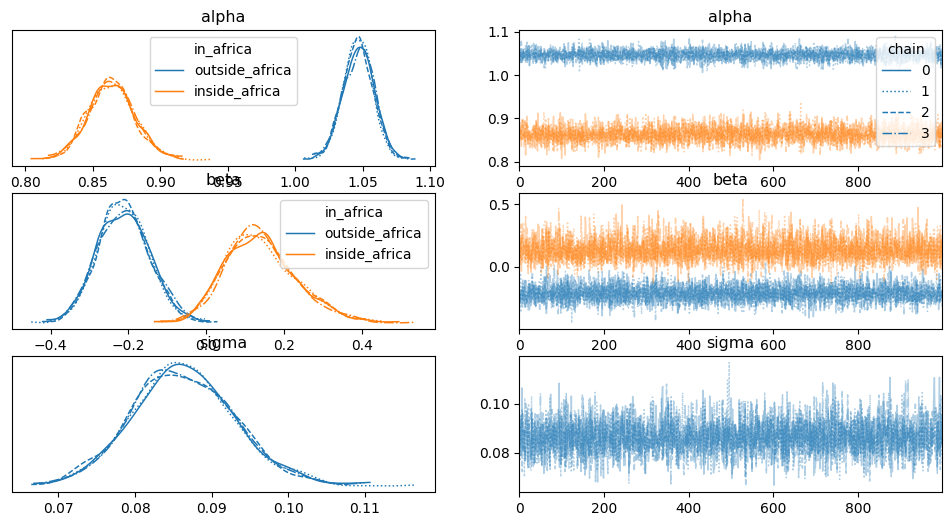

In [5]:
az.plot_trace(posterior, legend=True, var_names=["~mu"])

In [6]:
waic = az.waic(posterior, pointwise=True)
loo = az.loo(posterior, pointwise=True)

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [7]:
df.with_columns(
    model_waic = waic.waic_i.to_numpy(),
    model_loo = loo.loo_i.to_numpy(),
).filter(pl.col("cont_africa") == 1)

country,rugged,rgdppc_2000,cont_africa,model_waic,model_loo
str,f64,f64,i64,f64,f64
"""Angola""",0.138342,0.879712,1,1.314548,1.314529
"""Burundi""",0.287004,0.75523,1,0.373948,0.373801
"""Benin""",0.022735,0.806156,1,1.281316,1.281269
"""Burkina Faso""",0.038052,0.810858,1,1.298403,1.29836
"""Botswana""",0.029184,1.050743,1,-0.712267,-0.71232
…,…,…,…,…,…
"""United Republic of Tanzania""",0.109158,0.734678,1,0.44077,0.440729
"""Uganda""",0.147211,0.836632,1,1.353551,1.353528
"""South Africa""",0.283941,1.074365,1,-0.58701,-0.587108
